# TASK 2: CUSTOMER SEGMENTATION


# Problem Statement

In [1]:
print("Customer Segmentation")
print("Group customers based on spending behavior")

Customer Segmentation
Group customers based on spending behavior


# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning Libraries

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Upload Dataset From Kaggle

In [5]:
from google.colab import files

uploaded = files.upload()

Saving mall customer.csv.zip to mall customer.csv.zip


In [8]:
import os

os.listdir()

['.config', 'mall customer.csv.zip', 'archive.zip', 'sample_data']

In [12]:
import zipfile

In [13]:
with zipfile.ZipFile("mall customer.csv.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [14]:
import os

os.listdir()

['.config',
 'mall customer.csv.zip',
 'Mall_Customers.csv',
 'archive.zip',
 'sample_data']

In [17]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")

# Load Dataset

In [18]:
df = pd.read_csv("Mall_Customers.csv")

# Display Dataset

In [19]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Dataset Information

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Select Features

In [21]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Feature Scaling

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Elbow Method

In [24]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Visualization

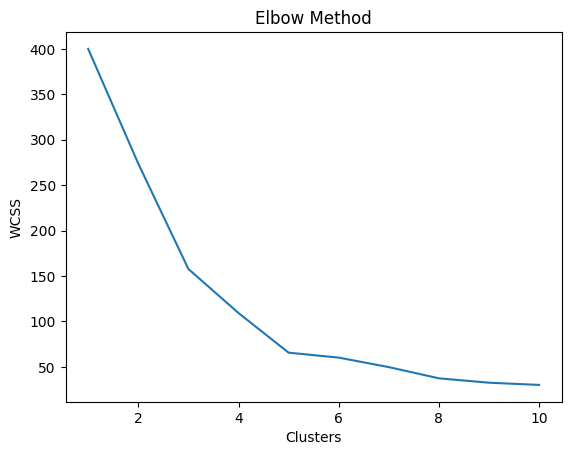

In [25]:
plt.plot(range(1, 11), wcss)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

# Apply KMeans

In [26]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Visualization

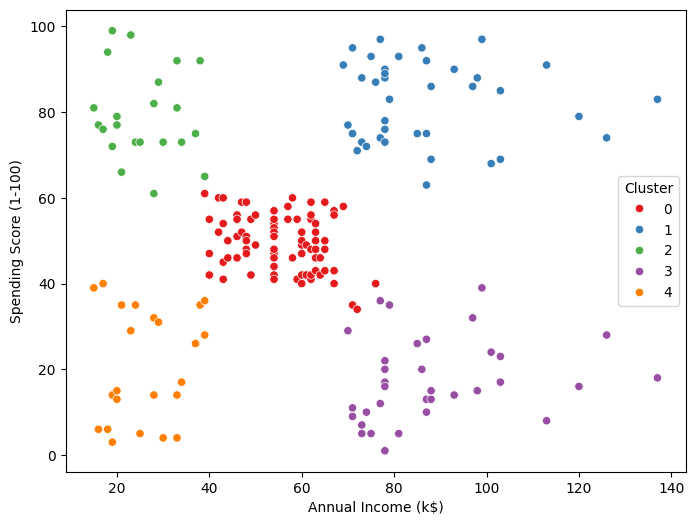

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1'
)

plt.show()

# Display Final Dataset

In [28]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# Conclusion

In [29]:
print("Customer groups identified successfully")

Customer groups identified successfully
